# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [154]:
#! pip install mne

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

from scripts import global_settings, trial_dynamics, sliding_window, erp_window

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data

In [156]:
# CONDITION   = "BLT"
# ONSET_MS = 500

CONDITION   = "BLA"
ONSET_MS = 0

SUBJECT_IDS = np.setdiff1d(np.arange(1,18,1), [1, 4, 14])
CHANNELS    = "all"                 # T7, T8, TP7, TP8
FREQ_BANDS  = "delta_beta"          # 0.5–30Hz
NORM_DICT = {
    "BASELINE": "center", # "center", "zscore", None
    "GLOBAL": None,   # "zscore", "max", None
}

all_sub_data = {}
all_data_bc_list = []
all_trial_rows = []

BASELINE_TMIN = -0.500
BASELINE_TMAX = -0.050

for sub_id in SUBJECT_IDS:
    epochs = load_eeg_data(CONDITION, sub_id, channels=CHANNELS, freq_band=FREQ_BANDS)

    data = epochs.get_data() * 1e6   # (n_trials, n_channels, n_times), µV
    times = epochs.times
    ch_names = epochs.ch_names
    sfreq = epochs.info["sfreq"]

    n_trials, n_channels, n_times = data.shape

    baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    baseline_std  = data[:, :, baseline_mask].std(axis=-1, keepdims=True)

    baseline_std[baseline_std == 0] = np.nan

    if NORM_DICT["BASELINE"] == "center":
        data_bc = data - baseline_mean
    elif NORM_DICT["BASELINE"] == "zscore":
        data_bc = (data - baseline_mean) / baseline_std   # z-score baseline corrected
    else:
        data_bc = data

    if NORM_DICT["GLOBAL"] == "zscore":
        global_mean = np.nanmean(data_bc)
        global_std = np.nanstd(data_bc)
        data_bc = (data_bc - global_mean) / global_std
    elif NORM_DICT["GLOBAL"] == "max":
        global_max = np.nanmax(np.abs(data_bc))
        data_bc = data_bc / global_max

    all_sub_data[sub_id] = {
        "epochs": epochs,
        "data": data,
        "data_bc": data_bc,
        "times": times,
        "ch_names": ch_names,
        "sfreq": sfreq,
        "n_trials": n_trials,
        "n_channels": n_channels,
        "n_times": n_times,
    }

    all_data_bc_list.append(data_bc)

    for t in range(n_trials):
        all_trial_rows.append({
            "sub_id": sub_id,
            "trial_index": t + 1,
        })

    print(
        f"Loaded Subject {sub_id} | trials={n_trials}, "
        f"channels={n_channels}, times={n_times}"
    )

ref_sub = SUBJECT_IDS[0]
times = all_sub_data[ref_sub]["times"]
ch_names = all_sub_data[ref_sub]["ch_names"]
time_ms = times * 1000

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 2 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 3 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Loaded Subject 15 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 16 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 17 | trials=60, channels=32, times=1792


In [157]:
# -------------------------
# 3.1) select channels for ROI grand average
# -------------------------
ROI_NAME = "all_rois"
SELECTED_CHANNELS = global_settings.roi_dict[ROI_NAME]

# -------------------------
# 3) concatenate all subjects after each was corrected separately
# -------------------------
all_data_bc = np.concatenate(all_data_bc_list, axis=0)   # (total_trials, n_channels, n_times)

print("All-subject concatenated data_bc shape:", all_data_bc.shape)



selected_idx = [ch_names.index(ch) for ch in SELECTED_CHANNELS if ch in ch_names]
selected_ch_names = [ch_names[i] for i in selected_idx]

all_data_bc_sel = all_data_bc[:, selected_idx, :]   # (total_trials, n_selected_channels, n_times)

print("Selected channels:", selected_ch_names)
print("all_data_bc_sel shape:", all_data_bc_sel.shape)

# channel-wise grand average on selected channels only
grand_avg_by_channel = np.nanmean(all_data_bc_sel, axis=0)   # (n_selected_channels, T)

# ROI average across selected channels
grand_avg = np.nanmean(grand_avg_by_channel, axis=0)   # (T,)

print("grand_avg_by_channel shape:", grand_avg_by_channel.shape)
print("grand_avg shape:", grand_avg.shape)

All-subject concatenated data_bc shape: (840, 32, 1792)
Selected channels: ['F3', 'FZ', 'F4', 'FC1', 'FC2', 'Cz', 'C3', 'C4', 'CP3', 'CPZ', 'CP4', 'CP1', 'CP2', 'P1', 'P2', 'POz']
all_data_bc_sel shape: (840, 16, 1792)
grand_avg_by_channel shape: (16, 1792)
grand_avg shape: (1792,)


In [158]:
print(ch_names)

['AF7', 'FPZ', 'AF8', 'AF3', 'AF4', 'F3', 'FZ', 'F4', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'POz', 'O1', 'Oz', 'O2']


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

           peak_idx  peak_time_ms  peak_amp  search_start_ms  search_end_ms  \
component                                                                     
P50             272     31.250000  0.182149             30.0          100.0   
N100            305     95.703125 -1.958825             80.0          160.0   
P200            349    181.640625  2.028670            150.0          250.0   
N200            419    318.359375 -0.142991            180.0          320.0   
P300            384    250.000000  0.328606            250.0          500.0   

          polarity  final_start_ms  final_end_ms  final_half_width_ms  
component                                                              
P50            pos       16.250000     46.250000                 15.0  
N100           neg       70.703125    120.703125                 25.0  
P200           pos      156.640625    206.640625                 25.0  
N200           neg      293.359375    343.359375                 25.0  
P300          

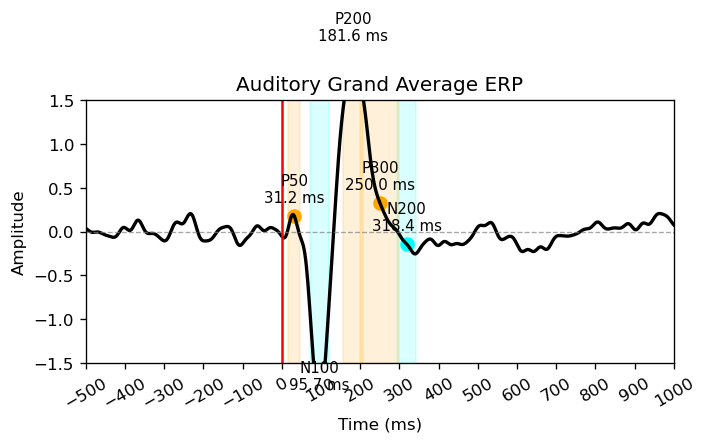

In [159]:
res_aud = erp_window.detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg,
    search_windows=global_settings.SEARCH_DICT[CONDITION]["search_windows"],
    onset_ms = ONSET_MS,
    polarity_map=global_settings.SEARCH_DICT[CONDITION]["polarity_map"],
    half_width_map=global_settings.half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

print(res_aud)
erp_window.plot_grand_avg_with_windows(
    time_ms=time_ms,
    grand_avg=grand_avg,
    res_df=res_aud,
    title="Auditory Grand Average ERP",
    onset_ms=ONSET_MS,
    figsize=(6,4)
)

## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [160]:
import numpy as np
import pandas as pd

# =========================
# 1) read time_wind
# =========================

component_windows = {
    comp: {
        "tmin_s": row["final_start_ms"] / 1000.0,
        "tmax_s": row["final_end_ms"] / 1000.0,
        "polarity": row["polarity"],
    }
    for comp, row in res_aud.iterrows()
}

print("Detected windows from res_aud:")
for comp, info in component_windows.items():
    print(
        f"  {comp}: {info['tmin_s']*1000:.1f}–{info['tmax_s']*1000:.1f} ms "
        f"(polarity={info['polarity']})"
    )

all_features_df_list = []
all_roi_features_df_list = [] 

for sub_id in SUBJECT_IDS:
    sub_pack = all_sub_data[sub_id]
    data_bc = sub_pack["data_bc"]          # (n_trials, n_channels, n_times)
    times   = sub_pack["times"]
    ch_names = SELECTED_CHANNELS

    n_trials, n_channels, _ = data_bc.shape

    # =========================
    # 1) build window masks
    # =========================
    window_masks = {}
    for comp, info in component_windows.items():
        mask = (times >= info["tmin_s"]) & (times <= info["tmax_s"])
        window_masks[comp] = mask

    # =========================
    # 2) extract mean amp
    # =========================
    feat_mean = {}
    for comp, mask in window_masks.items():
        # (n_trials, n_channels)
        feat_mean[comp] = np.nanmean(data_bc[:, :, mask], axis=-1)

    # =========================
    # 3) extract peak amp / latency
    # =========================
    feat_peak_amp = {}
    feat_peak_lat_ms = {}

    for comp, mask in window_masks.items():
        polarity = component_windows[comp]["polarity"]
        times_win = times[mask]
        win_data = data_bc[:, :, mask]   # (n_trials, n_channels, samples)

        if polarity == "pos":
            peak_ix = np.nanargmax(win_data, axis=-1)
        elif polarity == "neg":
            peak_ix = np.nanargmin(win_data, axis=-1)
        else:
            raise ValueError(f"Unknown polarity for {comp}: {polarity}")

        peak_amp = np.take_along_axis(
            win_data,
            peak_ix[..., None],
            axis=-1
        ).squeeze(-1)

        peak_lat_ms = times_win[peak_ix] * 1000.0

        feat_peak_amp[comp] = peak_amp
        feat_peak_lat_ms[comp] = peak_lat_ms

    # =========================
    # 4) trial × channel features_df
    # =========================
    rows = []
    for t in range(n_trials):
        for c, ch in enumerate(ch_names):
            row = {
                "sub_id": sub_id,
                "trial_index": t + 1,
                "channel": ch,
            }

            for comp in component_windows.keys():
                row[f"{comp}_mean_amp"] = feat_mean[comp][t, c]
                row[f"{comp}_peak_amp"] = feat_peak_amp[comp][t, c]
                row[f"{comp}_peak_lat_ms"] = feat_peak_lat_ms[comp][t, c]

            rows.append(row)

    features_df_sub = pd.DataFrame(rows)
    all_features_df_list.append(features_df_sub)

    # =========================
    # 5) ROI average across channels
    # =========================
    roi_rows = []
    for t in range(n_trials):
        row = {
            "sub_id": sub_id,
            "trial_index": t + 1,
        }

        for comp in component_windows.keys():
            row[f"{comp}_mean_amp_roi"] = np.nanmean(feat_mean[comp][t])
            row[f"{comp}_peak_amp_roi"] = np.nanmean(feat_peak_amp[comp][t])
            row[f"{comp}_peak_lat_ms_roi"] = np.nanmean(feat_peak_lat_ms[comp][t])

        roi_rows.append(row)

    roi_features_df_sub = pd.DataFrame(roi_rows)
    all_roi_features_df_list.append(roi_features_df_sub)

erp_features_all_df = pd.concat(all_features_df_list, ignore_index=True)
erp_roi_features_all_df = pd.concat(all_roi_features_df_list, ignore_index=True)

print("Per-channel feature df:")
display(erp_features_all_df.head())

print("ROI feature df:")
display(erp_roi_features_all_df.head())

Detected windows from res_aud:
  P50: 16.2–46.2 ms (polarity=pos)
  N100: 70.7–120.7 ms (polarity=neg)
  P200: 156.6–206.6 ms (polarity=pos)
  N200: 293.4–343.4 ms (polarity=neg)
  P300: 200.0–300.0 ms (polarity=pos)
Per-channel feature df:


,sub_id,trial_index,channel,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,P200_peak_lat_ms,N200_mean_amp,N200_peak_amp,N200_peak_lat_ms,P300_mean_amp,P300_peak_amp,P300_peak_lat_ms
0,2,1,F3,1.487736,2.717525,35.156250,0.157404,-5.326895,115.234375,3.478266,5.619188,177.734375,-2.321968,-5.367182,341.796875,-0.472966,4.699263,257.812500
1,2,1,FZ,-0.832668,2.371300,42.968750,-0.874574,-5.326267,117.187500,4.618665,6.624359,183.593750,-4.265699,-6.450892,294.921875,1.577328,5.821807,201.171875
2,2,1,F4,2.735125,6.050375,44.921875,0.590673,-7.536658,117.187500,2.363241,5.523103,181.640625,4.875067,1.622488,294.921875,3.379556,7.457814,259.765625
3,2,1,FC1,-0.487918,3.091058,44.921875,0.076266,-3.430305,117.187500,9.444203,11.911190,177.734375,-1.817845,-3.611195,294.921875,5.733668,10.621531,201.171875
4,2,1,FC2,-2.582907,1.111704,44.921875,-2.112433,-8.403151,119.140625,5.238448,9.992707,205.078125,-1.927792,-2.970701,341.796875,5.317702,10.306683,210.937500


ROI feature df:


,sub_id,trial_index,P50_mean_amp_roi,P50_peak_amp_roi,P50_peak_lat_ms_roi,N100_mean_amp_roi,N100_peak_amp_roi,N100_peak_lat_ms_roi,P200_mean_amp_roi,P200_peak_amp_roi,P200_peak_lat_ms_roi,N200_mean_amp_roi,N200_peak_amp_roi,N200_peak_lat_ms_roi,P300_mean_amp_roi,P300_peak_amp_roi,P300_peak_lat_ms_roi
0,2,1,-6.918947e-09,2.633721,29.113770,-7.342656e-08,-4.419588,93.505859,2.244896e-08,5.542910,179.016113,3.641996e-08,-2.700888,323.120117,3.634687e-08,4.867493,259.826660
1,2,2,2.091444e-08,1.821514,31.799316,3.361584e-08,-4.227944,92.346191,5.828774e-08,4.474503,181.762695,2.087667e-08,-3.959307,320.373535,2.905672e-08,6.428736,243.896484
2,2,3,1.723964e-08,3.034430,30.090332,-1.386056e-08,-5.138593,98.022461,3.671611e-08,5.622754,182.128906,3.124034e-11,-5.702564,322.265625,4.633111e-08,7.485134,237.731934
3,2,4,1.532810e-09,2.843922,33.935547,7.598992e-08,-2.785272,91.369629,-5.992850e-08,5.205558,185.913086,-4.210195e-08,-3.052410,318.237305,-3.656988e-09,5.545772,240.051270
4,2,5,-8.460703e-09,2.263724,30.700684,7.170293e-08,-4.341662,98.083496,2.993911e-08,3.792952,183.654785,-2.166860e-08,-3.774873,318.908691,1.684386e-08,4.594175,239.501953


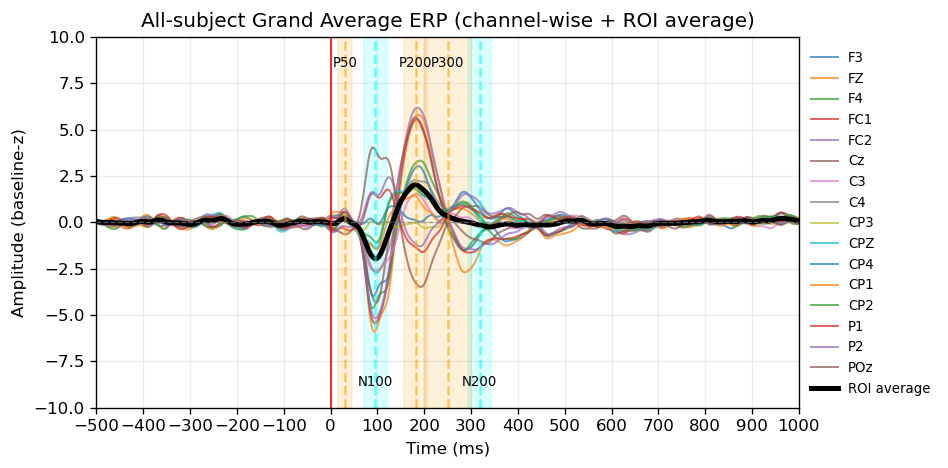

In [177]:
fig, ax = plt.subplots(figsize=(8, 4))
observe_range = 10
for c, ch in enumerate(ch_names):
    ax.plot(
        time_ms,
        grand_avg_by_channel[c],
        linewidth=1.2,
        alpha=0.7,
        label=ch
    )

ax.plot(
    time_ms,
    grand_avg,
    color="black",
    linewidth=3,
    label="ROI average"
)

min_amp = np.nanmin(grand_avg)
max_amp = np.nanmax(grand_avg)

for comp, row in res_aud.iterrows():
    color = "orange" if row["polarity"] == "pos" else "cyan"
    text_pos_y = -observe_range * 0.9 if row["polarity"] == "neg" else observe_range * 0.9
    ax.axvspan(
        row["final_start_ms"],
        row["final_end_ms"],
        alpha=0.15,
        color=color
    )
    ax.axvline(row["peak_time_ms"], linestyle="--", alpha=0.6, color=color)
    
    ax.text(
        row["peak_time_ms"],
        text_pos_y,
        comp,
        fontsize=8,
        ha="center",
        va="bottom" if row["polarity"] == "neg" else "top",
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(ONSET_MS, color="red", linestyle="-", linewidth=1, alpha=1.0)

ax.set_title("All-subject Grand Average ERP (channel-wise + ROI average)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (baseline-z)")
ax.set_xlim(-500+ONSET_MS, 800+ONSET_MS)
ax.set_xticks(np.arange(-500+ONSET_MS, 1001+ONSET_MS, 100))
ax.set_ylim(-observe_range, observe_range)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower left", bbox_to_anchor=(1.0, 0), fontsize=8,frameon=False)

plt.tight_layout()
plt.show()

## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

In [162]:
erp_roi_features_df, erp_roi_roll_df, erp_roi_group_roll_df = sliding_window.aggregate(
    erp_features_all_df,
    component_windows=component_windows,
    ROI_NAME=ROI_NAME,
    CONDITION=CONDITION,
)

CONDITION = all_rois
Subregions: ['F', 'FC', 'C', 'CP', 'P', 'PO']

Processing region = F, channels = ['F3', 'FZ', 'F4']

Processing region = FC, channels = ['FC1', 'FC2']

Processing region = C, channels = ['C3', 'Cz', 'C4']

Processing region = CP, channels = ['CP3', 'CPZ', 'CP4']

Processing region = P, channels = ['P1', 'P2']

Processing region = PO, channels = ['POz']

[Per-subject region-aggregated features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,P200_peak_lat_ms,N200_mean_amp,N200_peak_amp,N200_peak_lat_ms,P300_mean_amp,P300_peak_amp,P300_peak_lat_ms,condition,region
0,2,1,1.130064,3.713067,41.015625,-0.042165,-6.063273,116.536458,3.486724,5.922217,180.989583,-0.570866,-3.398529,310.546875,1.494639,5.992961,239.583333,BLA,F
1,2,2,3.221321,5.882438,20.182292,2.779263,-0.393939,110.026042,3.355849,7.758165,168.619792,-4.157274,-7.667076,301.432292,0.799538,6.774802,241.536458,BLA,F
2,2,3,10.713237,13.485648,38.411458,5.538238,-0.191249,118.489583,6.386686,12.083515,188.151042,0.530463,-5.542246,338.541667,7.198446,14.321974,238.932292,BLA,F
3,2,4,-2.984912,-0.545989,25.390625,-15.239947,-17.976908,104.817708,-11.581737,-2.926074,205.078125,-6.578506,-9.171592,307.291667,-9.583875,-2.277737,236.328125,BLA,F
4,2,5,9.489895,10.438951,32.552083,0.501514,-3.208572,119.140625,0.075841,3.349677,194.661458,-2.246008,-4.612787,328.125000,-2.287776,2.342983,212.239583,BLA,F



[Per-subject rolling features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,...,N100_peak_lat_ms_roll,P200_mean_amp_roll,P200_peak_amp_roll,P200_peak_lat_ms_roll,N200_mean_amp_roll,N200_peak_amp_roll,N200_peak_lat_ms_roll,P300_mean_amp_roll,P300_peak_amp_roll,P300_peak_lat_ms_roll
0,2,1,1.130064,3.713067,41.015625,-0.042165,-6.063273,116.536458,3.486724,5.922217,...,115.017361,4.409753,8.587965,179.253472,-1.399226,-5.535950,316.840278,3.164208,9.029912,240.017361
1,2,2,3.221321,5.882438,20.182292,2.779263,-0.393939,110.026042,3.355849,7.758165,...,112.467448,0.411880,5.709456,185.709635,-2.694046,-6.444861,314.453125,-0.022813,6.203000,239.095052
2,2,3,10.713237,13.485648,38.411458,5.538238,-0.191249,118.489583,6.386686,12.083515,...,113.802083,0.344673,5.237500,187.500000,-2.604438,-6.078446,317.187500,-0.475805,5.430997,233.723958
3,2,4,-2.984912,-0.545989,25.390625,-15.239947,-17.976908,104.817708,-11.581737,-2.926074,...,110.546875,-0.253315,4.715835,189.192708,-3.184767,-7.061997,321.614583,-0.784554,5.073843,236.718750
4,2,5,9.489895,10.438951,32.552083,0.501514,-3.208572,119.140625,0.075841,3.349677,...,110.156250,-2.698290,2.552982,192.708333,-2.912659,-6.469718,324.739583,-2.365221,3.658322,243.098958



[Grand average rolling features]


,trial_index,condition,region,P50_mean_amp_roll_mean,P50_mean_amp_roll_sem,P50_peak_amp_roll_mean,P50_peak_amp_roll_sem,P50_peak_lat_ms_roll_mean,P50_peak_lat_ms_roll_sem,N100_mean_amp_roll_mean,...,N200_peak_amp_roll_mean,N200_peak_amp_roll_sem,N200_peak_lat_ms_roll_mean,N200_peak_lat_ms_roll_sem,P300_mean_amp_roll_mean,P300_mean_amp_roll_sem,P300_peak_amp_roll_mean,P300_peak_amp_roll_sem,P300_peak_lat_ms_roll_mean,P300_peak_lat_ms_roll_sem
0,1,BLA,C,0.005670,0.749104,2.720349,0.727368,30.180432,1.288592,-4.444753,...,-2.230431,0.465137,319.211930,2.469153,3.514628,0.998072,9.495967,1.257908,235.026042,3.271701
1,2,BLA,C,0.509704,0.650378,3.193566,0.663486,30.378069,1.327392,-4.295886,...,-2.740369,0.331904,317.638579,2.230139,2.369169,0.676909,8.485458,0.971408,235.525949,3.520197
2,3,BLA,C,0.448272,0.628110,3.190972,0.627661,31.305804,1.138630,-4.535070,...,-3.199676,0.317527,317.354911,1.999340,1.666407,0.602550,8.083579,0.846279,234.412202,3.741181
3,4,BLA,C,1.111470,0.482495,3.911688,0.608899,32.263765,1.398207,-4.850816,...,-4.363419,0.488046,317.531622,1.856970,0.491527,0.570726,7.101822,0.806447,233.100818,4.154580
4,5,BLA,C,0.949016,0.516217,3.779711,0.562042,32.356771,1.081570,-5.149659,...,-4.619738,0.585073,317.429315,2.030108,-0.398496,0.544595,6.558452,0.859325,233.965774,4.501077


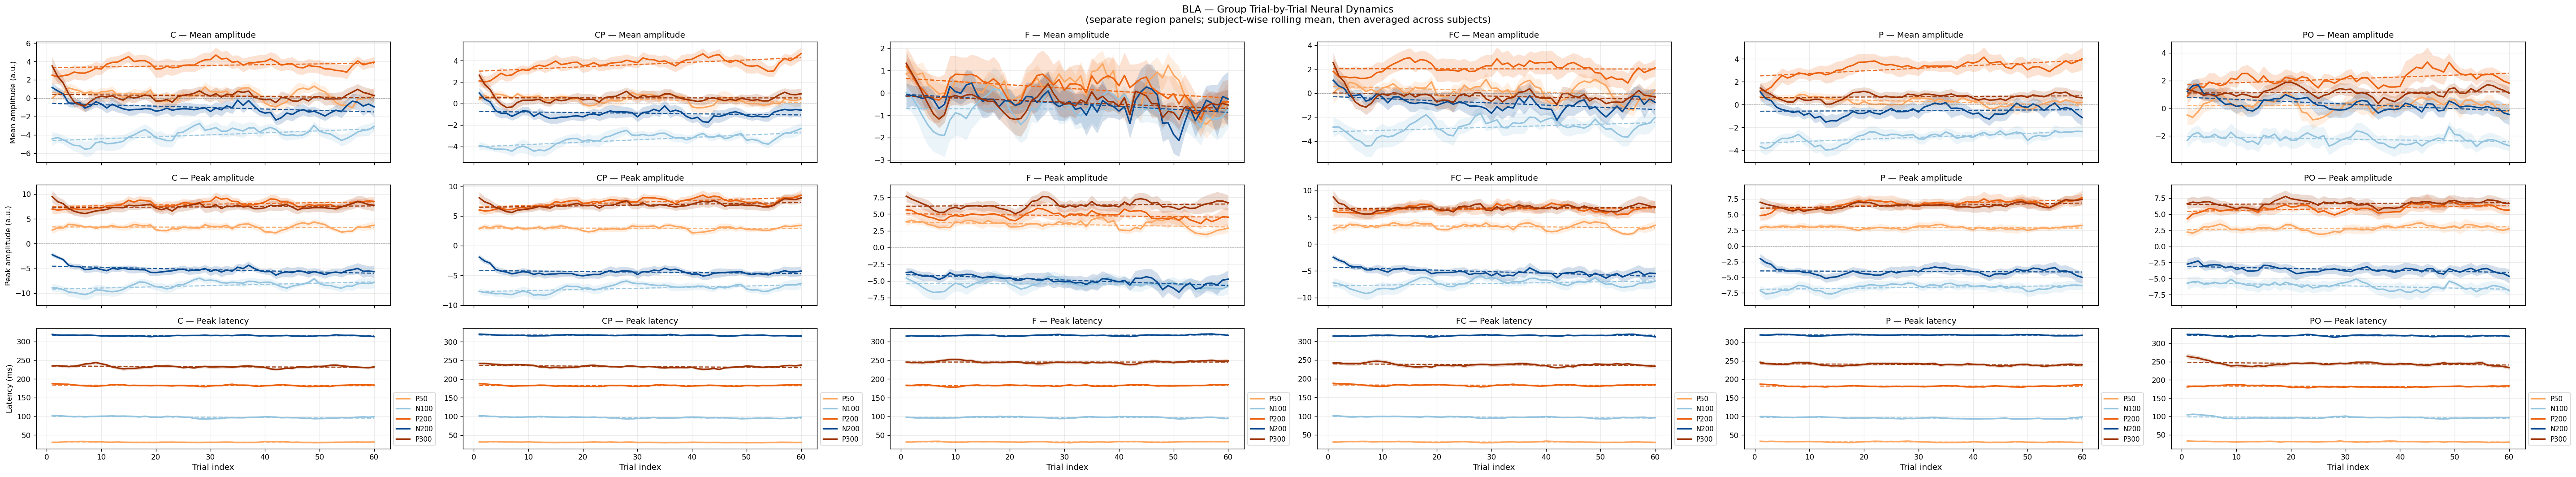

,region,component,metric_suffix,metric_title,mean_col,slope,intercept,rvalue,r2,pvalue,stderr,n
0,C,P50,mean_amp_roll_mean,Mean amplitude,P50_mean_amp_roll_mean,-0.010284,0.636683,-0.301881,0.091132,0.019071,0.004265,60
1,C,N100,mean_amp_roll_mean,Mean amplitude,N100_mean_amp_roll_mean,0.021728,-4.653819,0.567374,0.321913,0.000002,0.004141,60
2,C,P200,mean_amp_roll_mean,Mean amplitude,P200_mean_amp_roll_mean,0.008400,3.321100,0.271690,0.073816,0.035737,0.003907,60
3,C,N200,mean_amp_roll_mean,Mean amplitude,N200_mean_amp_roll_mean,-0.015605,-0.561387,-0.442016,0.195378,0.000407,0.004158,60
4,C,P300,mean_amp_roll_mean,Mean amplitude,P300_mean_amp_roll_mean,-0.006257,0.421172,-0.163174,0.026626,0.212868,0.004968,60
...,...,...,...,...,...,...,...,...,...,...,...,...
85,PO,P50,peak_lat_ms_roll_mean,Peak latency,P50_peak_lat_ms_roll_mean,-0.026645,31.835578,-0.481534,0.231875,0.000098,0.006368,60
86,PO,N100,peak_lat_ms_roll_mean,Peak latency,N100_peak_lat_ms_roll_mean,-0.059881,98.938763,-0.374234,0.140051,0.003223,0.019484,60
87,PO,P200,peak_lat_ms_roll_mean,Peak latency,P200_peak_lat_ms_roll_mean,-0.042959,183.500454,-0.362679,0.131536,0.004401,0.014494,60
88,PO,N200,peak_lat_ms_roll_mean,Peak latency,N200_peak_lat_ms_roll_mean,-0.026350,321.674161,-0.257325,0.066216,0.047160,0.012993,60


In [163]:
res_df = trial_dynamics.plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=True,
    b_fit_linear=True,
    b_plot_fit=True,
)
display(res_df)

res_df.to_csv(f"output/{CONDITION}_{ROI_NAME}_trial_dynamics_results.csv", index=False)

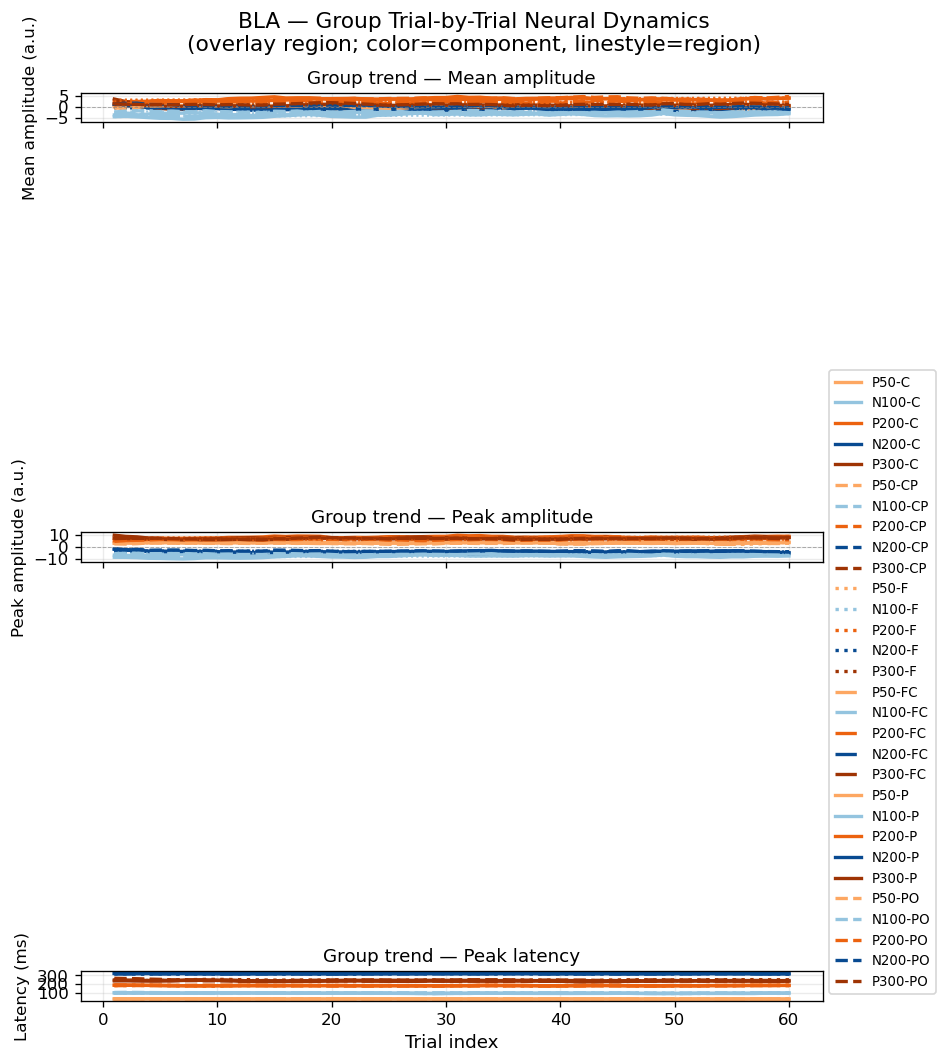

In [164]:
_ = trial_dynamics.plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=False,
    b_fit_linear=True,
    b_plot_fit=True,
)